# Hotel Bookings Cancellation Project

## Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset 

In [2]:
df = pd.read_csv('hotel_bookings.csv')

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-2015


## Exploratory Data Analysis  

In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 119390
Number of Columns: 32


In [5]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [6]:
# Data Types of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
# Converting 'reservation_status_date' from object to DateTime data type.
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'], dayfirst=True)

In [8]:
# Verifying the data type again
df['reservation_status_date'].dtype

dtype('<M8[ns]')

In [9]:
print(df[['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month']].isnull().sum())

arrival_date_year            0
arrival_date_month           0
arrival_date_day_of_month    0
dtype: int64


In [10]:
# Creating arrival date column from string format 
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'].astype(str) + '-' + 
    df['arrival_date_day_of_month'].astype(str), 
    format = '%Y-%B-%d', dayfirst=True
)

In [11]:
# Descriptive Statistics
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166


In [12]:
# NULL values
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [13]:
# Replacing '0' in-place of NULL for children column
df['children'].fillna(0, inplace=True)

In [14]:
# Replacing missing 'country' values with 'Unknown'
df['country'].fillna('Unknown', inplace=True)

In [15]:
# Based on dataset documentation: 
  #agent: ID of travel agency (null = direct booking)
  #company: ID of paying company (null = individual guest)

# Creating a flag for corporate booking
df['is_corporate_booking'] = df['company'].notna().astype(int)

print(df['is_corporate_booking'].value_counts())

is_corporate_booking
0    112593
1      6797
Name: count, dtype: int64


In [16]:
# Dropping the 'company' column
df = df.drop('company', axis=1)

### Handling Sparse 'company' column
As per dataset documentation, 'company' contains anonymized IDs of the paying entity. 

112,593 nulls - Individual Guests

6,797 non-nulls - Corporate Bookings

Created 'is_corporate_booking' flag to capture the segmentation. 

In [17]:
# Cleaning 'agent' column
df['booked_via_agent'] = df['agent'].notna().astype(int)
df = df.drop('agent', axis=1) 

In [18]:
print(df['booked_via_agent'].value_counts())

booked_via_agent
1    103050
0     16340
Name: count, dtype: int64


### Handling Sparse 'agent' column
1,03,050 nulls - Direct Booking (Hotel website, phone, walk-in)

16,340 non-nulls - Booking through a travel agency.

In [19]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,arrival_date,is_corporate_booking,booked_via_agent
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390,119390,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103886,0.007949,...,0.137097,0.221124,2.321149,101.831122,0.062518,0.571363,2016-07-30 00:24:47.883407104,2016-08-28 16:39:45.727447808,0.056931,0.863138
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00,2015-07-01 00:00:00,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,69.290000,0.000000,0.000000,2016-02-01 00:00:00,2016-03-13 00:00:00,0.000000,1.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,94.575000,0.000000,0.000000,2016-08-07 00:00:00,2016-09-06 00:00:00,0.000000,1.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-08 00:00:00,2017-03-18 00:00:00,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,...,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00,2017-08-31 00:00:00,1.000000,1.000000
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398555,0.097436,...,1.497437,0.652306,17.594721,50.535790,0.245291,0.792798,NaN,NaN,0.231712,0.343703


### Outlier Removal
Max value of ADR is $5,400, which is an extreme outlier. 

In [20]:
df = df[df['adr']<5000]

## Data Analysis & Visualizations

In [21]:
# Overall Cancellation Rate
overall_cancel_rate = df['is_canceled'].mean()
print(f"Overall cancellation percentage: {overall_cancel_rate:.1%}")

Overall cancellation percentage: 37.0%


In [22]:
overall_cancel_rate = df['is_canceled'].value_counts()
overall_cancel_rate

is_canceled
0    75166
1    44223
Name: count, dtype: int64

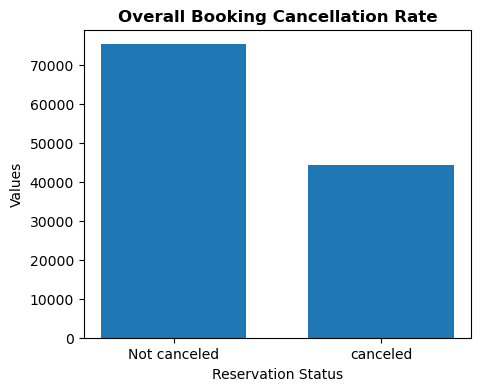

In [23]:
plt.figure(figsize = (5,4))
plt.title('Overall Booking Cancellation Rate', fontsize=12, fontweight='bold')
plt.bar(['Not canceled', 'canceled'], df['is_canceled'].value_counts(), width=0.7)
plt.xlabel('Reservation Status')
plt.ylabel('Values')
plt.show()

In [24]:
# Cancellation by Hotel Type
hotel_cancel = df.groupby('hotel')['is_canceled'].mean()
print("Cancellation rate by hotel:")
print(hotel_cancel.apply(lambda x: f"{x:.1%}"))

Cancellation rate by hotel:
hotel
City Hotel      41.7%
Resort Hotel    27.8%
Name: is_canceled, dtype: object


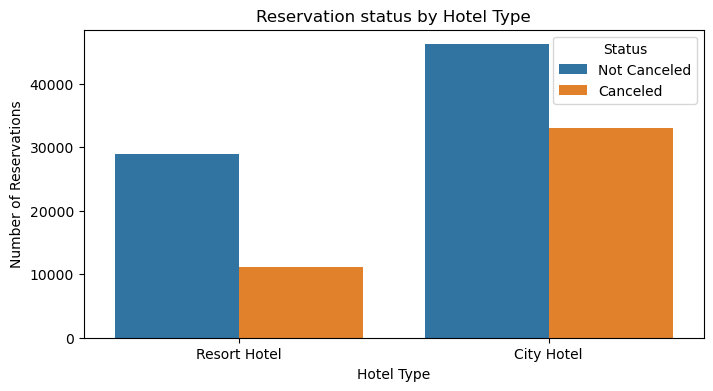

In [25]:
plt.figure(figsize = (8,4))
ax1=sns.countplot(x='hotel', hue='is_canceled', data = df)
plt.title('Reservation status by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Reservations')
plt.legend(title='Status', labels=['Not Canceled', 'Canceled'])
plt.show()

In [26]:
# Cancellation by Deposit Type
deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean()
print("Cancellation rate by deposit type:")
print(deposit_cancel.apply(lambda x: f"{x:.1%}"))

Cancellation rate by deposit type:
deposit_type
No Deposit    28.4%
Non Refund    99.4%
Refundable    22.2%
Name: is_canceled, dtype: object


In [27]:
# Check counts for "Non Refund"
non_refund = df[df['deposit_type'] == 'Non Refund']
print("Non Refund bookings:")
print("Total:", len(non_refund))
print("Canceled (is_canceled=1):", non_refund['is_canceled'].sum())
print("Not Canceled (is_canceled=0):", (non_refund['is_canceled'] == 0).sum())

Non Refund bookings:
Total: 14586
Canceled (is_canceled=1): 14493
Not Canceled (is_canceled=0): 93


### Note on "Non Refund" Cancellations
99.4% of "Non Refund" bookings are canceled. As per the dataset authors, these are often fraudulent or visa-support bookings made with invalid payment details. Excluding this area from analysis.

In [28]:
# Cancellation rate by Booking Channel Type 
agent_cancel = df.groupby('booked_via_agent')['is_canceled'].mean()
print("Cancellation rate by booking channel:")
print("Direct booking    :", f"{agent_cancel[0]:.1%}")
print("Travel agent      :", f"{agent_cancel[1]:.1%}")

Cancellation rate by booking channel:
Direct booking    : 24.7%
Travel agent      : 39.0%


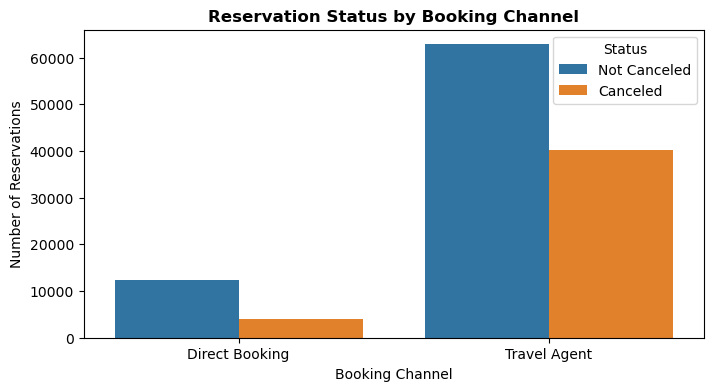

In [29]:
plt.figure(figsize=(8, 4))
ax1 = sns.countplot(x='booked_via_agent', hue='is_canceled', data=df)
plt.title('Reservation Status by Booking Channel', fontweight='bold')
plt.xlabel('Booking Channel')
plt.ylabel('Number of Reservations')
plt.xticks([0,1], ['Direct Booking', 'Travel Agent'])
plt.legend(title='Status', labels=['Not Canceled', 'Canceled'])
plt.show()

In [30]:
# Cancellation rate by agent and deposit type
combination = df.groupby(['booked_via_agent', 'deposit_type'])['is_canceled'].mean().unstack()

combination.index = ['Direct', 'Travel Agent']
print("Cancellation Rate by Channel & Deposit Type:")
print((combination * 100).round(1).astype(str) + '%')

Cancellation Rate by Channel & Deposit Type:
deposit_type No Deposit Non Refund Refundable
Direct            14.2%      98.1%      10.5%
Travel Agent      30.6%      99.6%      50.0%


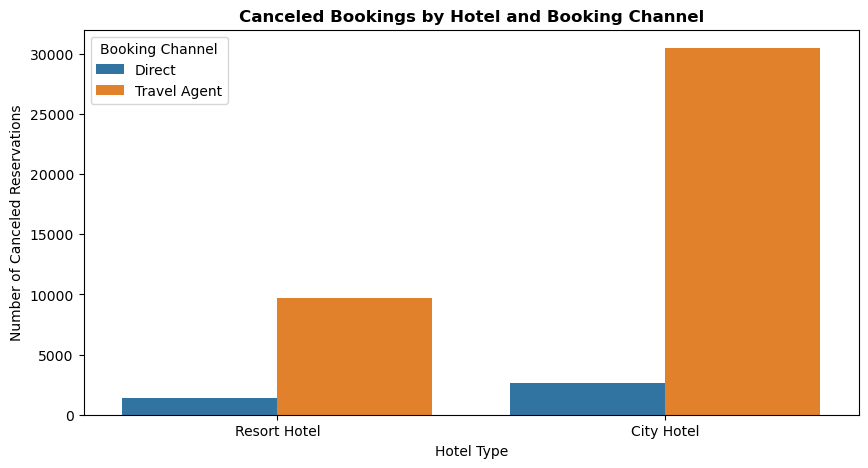

In [31]:
plt.figure(figsize=(10, 5))
sns.countplot(x='hotel', hue='booked_via_agent', data=df[df['is_canceled'] == 1])
plt.title('Canceled Bookings by Hotel and Booking Channel', fontweight='bold')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Canceled Reservations')
plt.legend(title='Booking Channel', labels=['Direct', 'Travel Agent'])
plt.show()

In [32]:
# Cancellation Rate by Customer Type
corp_cancel = df.groupby('is_corporate_booking')['is_canceled'].mean()
print("Cancellation rate by customer type:")
print("Individual guests :", f"{corp_cancel[0]:.1%}")
print("Corporate guests  :", f"{corp_cancel[1]:.1%}")

Cancellation rate by customer type:
Individual guests : 38.2%
Corporate guests  : 17.5%


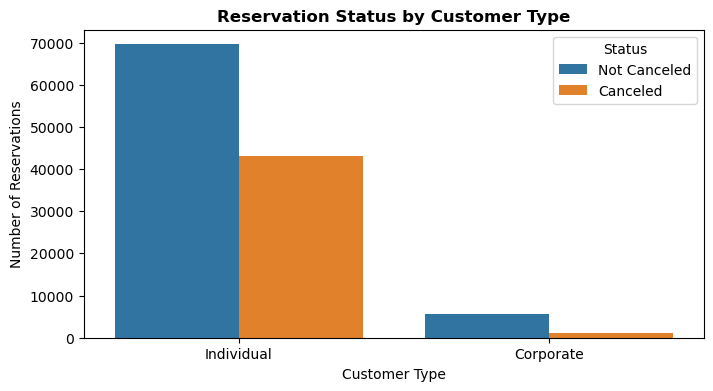

In [33]:
plt.figure(figsize=(8, 4))
ax1 = sns.countplot(x='is_corporate_booking', hue='is_canceled', data=df)
plt.title('Reservation Status by Customer Type', fontweight='bold')
plt.xlabel('Customer Type')
plt.ylabel('Number of Reservations')
plt.xticks([0, 1], ['Individual', 'Corporate']) 
plt.legend(title='Status', labels=['Not Canceled', 'Canceled'])
plt.show()

In [34]:
# Calculating Average ADR for canceled vs. non-canceled
adr_by_status = df.groupby('is_canceled')['adr'].mean()
adr_by_status.index = ['Not Canceled', 'Canceled']

print("Average ADR by Cancellation Status:")
for status, adr in adr_by_status.items():
    print(f"{status}: ${adr:.2f}")

Average ADR by Cancellation Status:
Not Canceled: $99.99
Canceled: $104.84


In [35]:
# Calculating revenue lost due to cancellations 
import numpy as np
df['lost_revenue'] = np.where(
    (df['is_canceled'] == 1) & (df['deposit_type'] != 'Non Refund'),
    df['adr'] * (df['stays_in_week_nights'] + df['stays_in_weekend_nights']),
    0
)  

print(f"Total Revenue Lost: ${df['lost_revenue'].sum():,.0f}")

lost_by_deposit = df.groupby('deposit_type')['lost_revenue'].sum()
print("Revenue Lost by Deposit Type:")
print((lost_by_deposit / 1000).round(0).astype(str) + 'K')

Total Revenue Lost: $13,122,900
Revenue Lost by Deposit Type:
deposit_type
No Deposit    13103.0K
Non Refund        0.0K
Refundable       20.0K
Name: lost_revenue, dtype: object


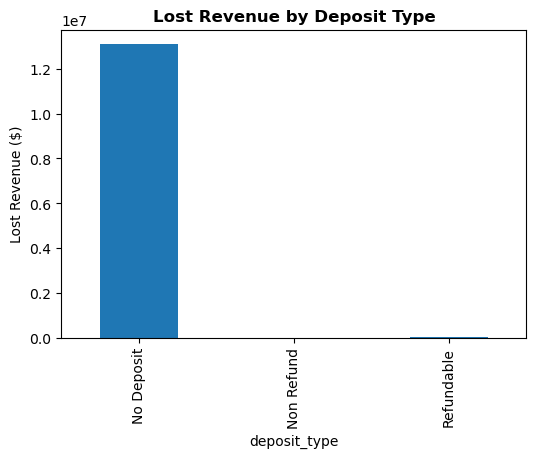

In [36]:
lost_by_deposit.plot(kind='bar', figsize=(6,4))
plt.title('Lost Revenue by Deposit Type', fontweight='bold')
plt.ylabel('Lost Revenue ($)')
plt.show()

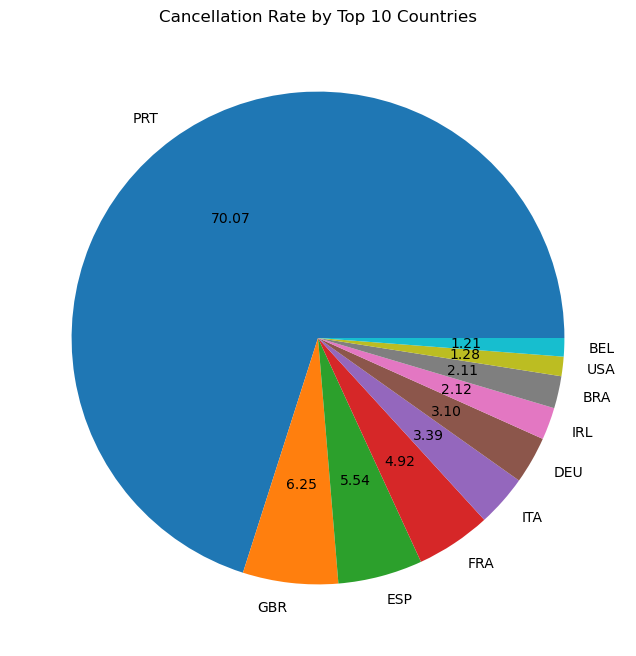

In [37]:
# Cancellation Rate by Top Countries
cancelled_data = df[df['is_canceled'] ==1]
top_10_country = cancelled_data['country'].value_counts().head(10)

plt.figure(figsize = (8,8))
plt.title('Cancellation Rate by Top 10 Countries')
plt.pie(top_10_country, autopct = '%.2f', labels = top_10_country.index)
plt.show()

In [38]:
# Market Segments
df['market_segment'].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24218
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [39]:
df['market_segment'].value_counts(normalize = True).mul(100).round(2)

market_segment
Online TA        47.31
Offline TA/TO    20.28
Groups           16.59
Direct           10.56
Corporate         4.44
Complementary     0.62
Aviation          0.20
Undefined         0.00
Name: proportion, dtype: float64

In [40]:
# Cancellation Rate by Market Segment
cancelled_data['market_segment'].value_counts(normalize = True).mul(100).round(2)

market_segment
Online TA        46.90
Groups           27.35
Offline TA/TO    18.79
Direct            4.37
Corporate         2.24
Complementary     0.22
Aviation          0.12
Undefined         0.00
Name: proportion, dtype: float64

In [41]:
# Creating lead time categories
df['lead_time_bin'] = pd.cut(
    df['lead_time'], 
    bins=[0, 60, 180, 365, 737], 
    labels=['<2 months', '2-6 months', '6-12 months', '12+ months']
)

In [42]:
# Calculating cancellation rate by lead time 
lead_cancel = df.groupby('lead_time_bin')['is_canceled'].mean()
print("Cancellation Rate by Lead Time:")
print(lead_cancel.apply(lambda x: f"{x:.1%}"))

Cancellation Rate by Lead Time:
lead_time_bin
<2 months      26.2%
2-6 months     43.0%
6-12 months    55.5%
12+ months     67.7%
Name: is_canceled, dtype: object


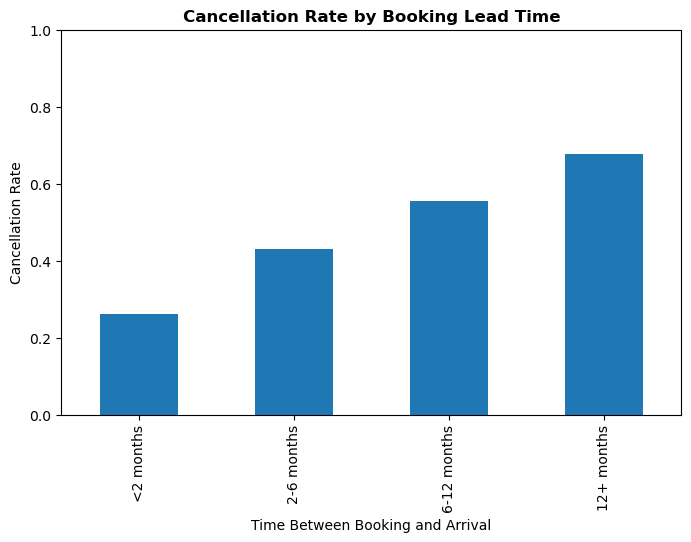

In [43]:
plt.figure(figsize=(8, 5))
lead_cancel.plot(kind='bar')
plt.title('Cancellation Rate by Booking Lead Time', fontweight='bold')
plt.ylabel('Cancellation Rate')
plt.xlabel('Time Between Booking and Arrival')
plt.ylim(0, 1)
plt.show()